# Aggregation methods — audit and standardisation

The paper has referred to means, medians, population-weighted means and Facebook-count ratios as
though they were interchangeable summaries of the regional gender gap. They are not. This notebook
computes all of them on one sample and one set of definitions, quantifies how far apart they land,
and attributes the difference to specific channels.

**Every figure title, table note and generated statistic here names its aggregation method.** That
is the point of the exercise: no number should leave this notebook without one.

| Method | What it averages |
| --- | --- |
| `mean_unweighted` | mean of country GGI — every country counts once |
| `median_unweighted` | median of country GGI — every country counts once, outliers discounted |
| `mean_pop_weighted_female` | country GGI, weighted by adult female population |
| `mean_pop_weighted_total` | country GGI, weighted by adult total population |
| `aggregate_ggi` | regional female rate / regional male rate, **each sex on its own 18+ denominator** |
| `aggregate_ggi_single_denom` | same, but one shared denominator — isolates the sex-structure effect |
| `aggregate_ggi_parity_capped` | `min(aggregate_ggi, 1)` (D25) |

Tables come from `src/16_aggregation_methods.py`; this notebook only plots and narrates.

In [1]:
import _bootstrap  # noqa: F401  — puts src/ on sys.path
import re
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import params

warnings.filterwarnings('ignore')

STYLE = params.STYLE
PALETTE = STYLE['colors']
INK, MUTED, GRID = '#222222', '#666666', '#d9d9d9'
FIGDIR = params.FIG / 'aggregation'
FIGDIR.mkdir(parents=True, exist_ok=True)

BASIS = 'fixed_2015'      # primary weighting basis; see the coverage audit below
GLOBAL = 'GLOBAL'


def latest(stem):
    matches = sorted(f for f in (params.OUTPUTS / 'tables').glob(f'aggregation_{stem}_*.csv')
                     if re.fullmatch(rf'aggregation_{stem}_\d{{8}}\.csv', f.name))
    if not matches:
        raise FileNotFoundError(f'no aggregation_{stem}_<date>.csv — run src/16_aggregation_methods.py')
    return pd.read_csv(matches[-1])


coverage     = latest('population_coverage')
methods      = latest('methods')
comparison   = latest('comparison_2015_2025')
decomposition = latest('difference_decomposition')
disagreement = latest('rank_disagreement')
labels       = latest('method_labels')

METHOD_LABEL = dict(zip(labels['method'], labels['label']))
METHOD_ORDER = list(labels['method'])
METHOD_COLOUR = dict(zip(METHOD_ORDER, PALETTE))


def tidy(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=STYLE['label_fs'], color=INK, fontweight='bold', loc='left')
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=STYLE['tick_fs'], color=MUTED)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=STYLE['tick_fs'], color=MUTED)
    ax.tick_params(labelsize=STYLE['tick_fs'] - 1, colors=MUTED)
    ax.grid(axis='y', color=GRID, linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_color(GRID)
    return ax


def caption(fig, text, y=-0.02):
    """
    a figure without its aggregation method named is not finished

    `y` drops the note below any figure-level legend; the default suits figures without one.
    """
    fig.text(0.01, y, text, ha='left', va='top', fontsize=STYLE['tick_fs'] - 1, color=MUTED)

## 1. Population denominator audit

Denominators are the **18+ population by sex** — the age group the national models are fitted on
(`params.FINAL_MODEL`), so this is an age-aligned denominator, not a stand-in. Total population is
computed alongside and reported, never silently substituted.

In [2]:
display(coverage)
gap = coverage[~coverage['contemporaneous_weighting_possible']]
print(f"Years with NO age/sex-specific denominator: {list(gap['year'])}")

,year,age_group,n_countries_modelled,n_with_sex_specific_pop,coverage_pct,contemporaneous_weighting_possible
0,2015,18_plus,211,211,100.0,True
1,2016,18_plus,211,211,100.0,True
2,2017,18_plus,211,211,100.0,True
3,2018,18_plus,211,211,100.0,True
4,2019,18_plus,211,211,100.0,True
5,2020,18_plus,211,211,100.0,True
6,2021,18_plus,211,211,100.0,True
7,2022,18_plus,211,211,100.0,True
8,2023,18_plus,211,211,100.0,True
9,2024,18_plus,211,211,100.0,True


Years with NO age/sex-specific denominator: [2025]


**The UN population file stops at 2024.** There is no 2025 population, so a population-weighted 2025
figure cannot use 2025 population — a fact any manuscript statistic weighted to 2025 must carry.

Two bases are therefore computed:

- **`fixed_2015`** (primary here) — the 2015 population structure applied to every year. The whole
  2015–2025 window is computable on one consistent weighting, and it matches the decomposition
  module (D24).
- **`contemporaneous`** — each year's own population. Correct in principle, available only to 2024.

Both are in `aggregation_methods_<date>.csv`; results below use `fixed_2015` unless stated.

## 2. All methods compared, 2015 and 2025

In [3]:
tbl = comparison[(comparison['weight_basis'] == BASIS)].copy()
tbl['method_label'] = tbl['method'].map(METHOD_LABEL)
display(tbl[(tbl['indicator'] == 'internet')]
        [['region', 'method_label', 'ggi_2015', 'ggi_2025', 'change', 'n_countries']]
        .round(4).reset_index(drop=True))
print('Table note: internet; coherent GGI (female/male predicted levels); weighting basis '
      f'{BASIS}; 18+ sex-specific population denominators.')

,region,method_label,ggi_2015,ggi_2025,change,n_countries
0,East Asia & Pacific,Aggregate GGI (sex-specific 18+ denominators),0.9142,0.9533,0.0392,37
1,Europe & Central Asia,Aggregate GGI (sex-specific 18+ denominators),0.9554,0.9861,0.0307,55
2,GLOBAL,Aggregate GGI (sex-specific 18+ denominators),0.8391,NaN,NaN,210
3,GLOBAL,Aggregate GGI (sex-specific 18+ denominators),NaN,0.8990,NaN,211
4,Latin America & Caribbean,Aggregate GGI (sex-specific 18+ denominators),0.9712,0.9941,0.0229,43
...,...,...,...,...,...,...
65,Middle East & North Africa,Unweighted median of country GGI,0.8437,0.9105,0.0668,18
66,North America,Unweighted median of country GGI,1.0269,1.0000,-0.0269,3
67,South Asia,Unweighted median of country GGI,0.6600,0.8284,0.1684,8
68,Sub-Saharan Africa,Unweighted median of country GGI,0.5598,NaN,NaN,46


Table note: internet; coherent GGI (female/male predicted levels); weighting basis fixed_2015; 18+ sex-specific population denominators.


In [4]:
# how far apart the methods land — the spread that any unlabelled statistic hides
spread = (tbl.groupby(['indicator', 'region'])
          .agg(min_2015=('ggi_2015', 'min'), max_2015=('ggi_2015', 'max'),
               min_2025=('ggi_2025', 'min'), max_2025=('ggi_2025', 'max'))
          .assign(spread_2015=lambda d: d['max_2015'] - d['min_2015'],
                  spread_2025=lambda d: d['max_2025'] - d['min_2025'])
          .reset_index())
display(spread.round(4))
print('Table note: range across the seven aggregation methods, same sample and definitions.')

,indicator,region,min_2015,max_2015,min_2025,max_2025,spread_2015,spread_2025
0,internet,East Asia & Pacific,0.9091,0.9396,0.9506,0.9644,0.0304,0.0138
1,internet,Europe & Central Asia,0.9554,0.9736,0.9835,0.9994,0.0182,0.0159
2,internet,GLOBAL,0.7489,0.9345,0.8794,0.9751,0.1856,0.0956
3,internet,Latin America & Caribbean,0.9570,0.9712,0.9820,0.9941,0.0142,0.0121
4,internet,Middle East & North Africa,0.7661,0.8437,0.8755,0.9182,0.0776,0.0427
5,internet,North America,1.0000,1.0283,0.9957,1.0000,0.0283,0.0043
6,internet,South Asia,0.5211,0.6600,0.7541,0.8284,0.1388,0.0743
7,internet,Sub-Saharan Africa,0.4405,0.5680,0.7745,0.8004,0.1275,0.0259
8,mobile,East Asia & Pacific,0.9554,0.9782,0.9816,1.0000,0.0228,0.0184
9,mobile,Europe & Central Asia,0.9788,0.9979,1.0000,1.0044,0.0191,0.0044


Table note: range across the seven aggregation methods, same sample and definitions.


## 3. Does the method change the regional ordering?

In [5]:
d = disagreement[disagreement['weight_basis'] == BASIS]
display(d[[c for c in d.columns if c != 'weight_basis']])
print('Table note: regional rank on the 2025 value under each aggregation method '
      f'(1 = highest GGI); weighting basis {BASIS}.')

,indicator,region,rank_mean_unweighted,rank_median_unweighted,n_distinct_ranks,max_rank_shift,rank_aggregate_ggi,rank_aggregate_ggi_parity_capped,rank_aggregate_ggi_single_denom,rank_mean_pop_weighted_female,rank_mean_pop_weighted_total
7,internet,East Asia & Pacific,4,4,1,0,4.0,4.0,4.0,4.0,4.0
8,internet,Europe & Central Asia,2,2,2,1,3.0,3.0,3.0,3.0,3.0
9,internet,Latin America & Caribbean,3,3,2,1,2.0,2.0,2.0,2.0,2.0
10,internet,Middle East & North Africa,5,5,1,0,5.0,5.0,5.0,5.0,5.0
11,internet,North America,1,1,1,0,1.0,1.0,1.0,1.0,1.0
12,internet,South Asia,7,6,2,1,7.0,7.0,7.0,7.0,7.0
13,internet,Sub-Saharan Africa,6,7,2,1,6.0,6.0,6.0,6.0,6.0
21,mobile,East Asia & Pacific,4,2,2,2,4.0,4.0,4.0,4.0,4.0
22,mobile,Europe & Central Asia,2,2,2,1,2.0,1.0,2.0,2.0,2.0
23,mobile,Latin America & Caribbean,1,1,1,0,1.0,1.0,1.0,1.0,1.0


Table note: regional rank on the 2025 value under each aggregation method (1 = highest GGI); weighting basis fixed_2015.


## 4. Regional trend under two summaries

The spec asks for the regional trend figure under the **regional median** and the
**population-weighted aggregate GGI**. Both are shown side by side, on identical samples, so the
difference is the method and nothing else.

  regional_trend_two_methods_internet.png


  regional_trend_two_methods_mobile.png


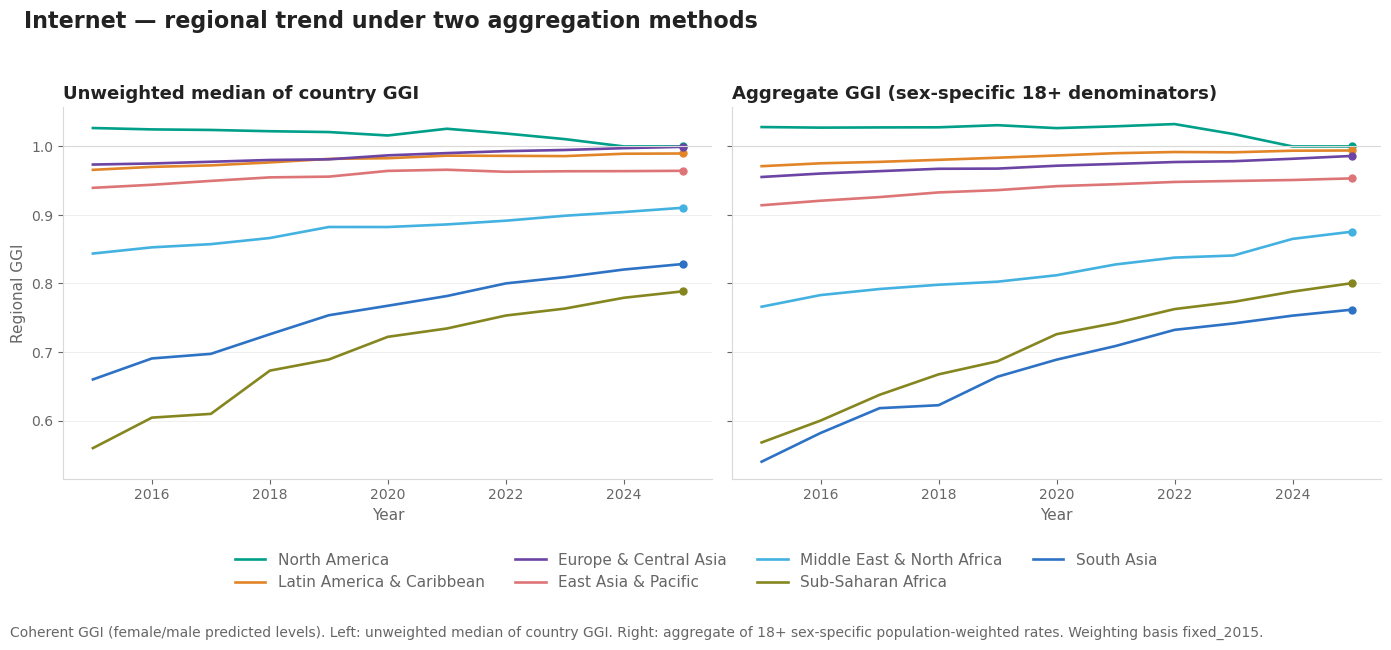

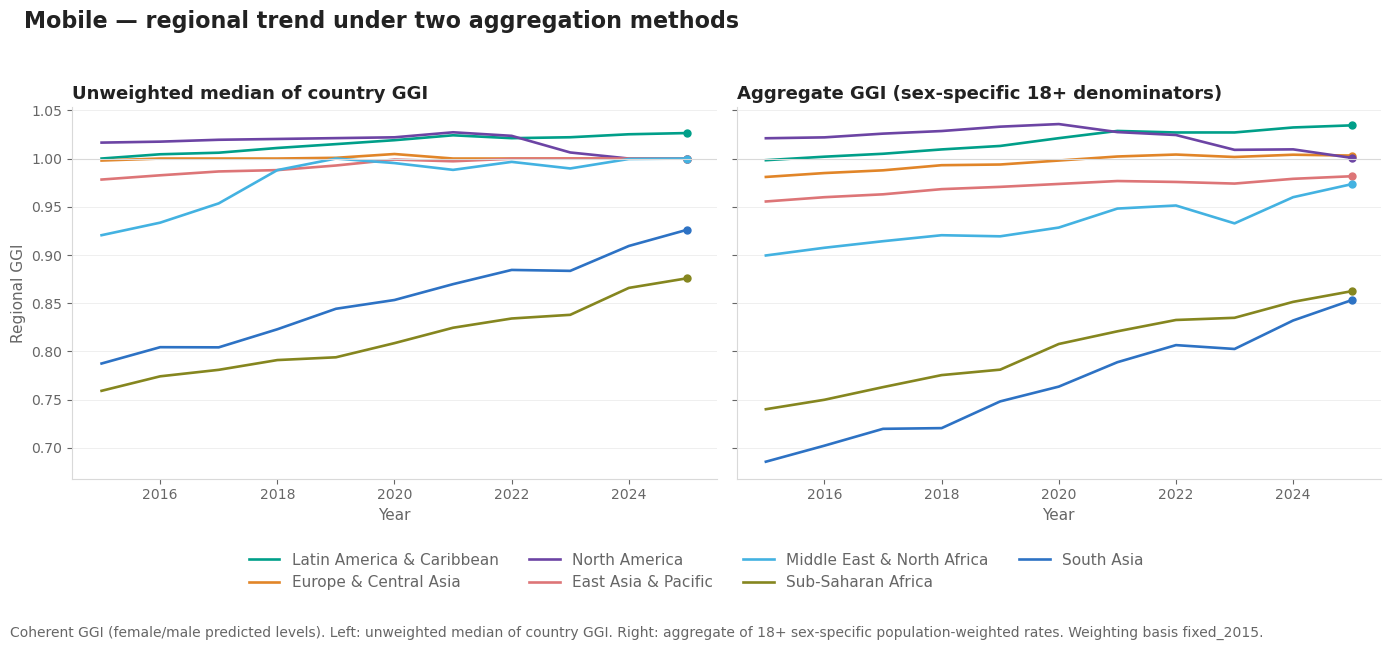

In [6]:
PAIR = ['median_unweighted', 'aggregate_ggi']

for indicator in params.COHERENT_GGI['indicators']:
    block = methods[(methods['indicator'] == indicator) & (methods['weight_basis'] == BASIS)
                    & (methods['region'] != GLOBAL)]
    regions = (block[block['year'] == 2025].sort_values('aggregate_ggi', ascending=False)['region']
               .tolist())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    for ax, method in zip(axes, PAIR):
        for i, region in enumerate(regions):
            line = block[block['region'] == region].sort_values('year')
            ax.plot(line['year'], line[method], linewidth=1.9,
                    color=PALETTE[i % len(PALETTE)])
            ax.plot(line['year'].iloc[-1], line[method].iloc[-1], 'o',
                    color=PALETTE[i % len(PALETTE)], markersize=5)
        ax.axhline(1.0, color=GRID, linewidth=0.8)
        tidy(ax, title=METHOD_LABEL[method], xlabel='Year')
    axes[0].set_ylabel('Regional GGI', fontsize=STYLE['tick_fs'], color=MUTED)

    handles = [plt.Line2D([], [], color=PALETTE[i % len(PALETTE)], linewidth=1.9, label=r)
               for i, r in enumerate(regions)]
    fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
               fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.10))
    fig.suptitle(f'{indicator.capitalize()} — regional trend under two aggregation methods',
                 fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
    caption(fig, f'Coherent GGI (female/male predicted levels). Left: unweighted median of country '
                 f'GGI. Right: aggregate of 18+ sex-specific population-weighted rates. '
                 f'Weighting basis {BASIS}.', y=-0.14)
    fig.tight_layout(rect=[0, 0.02, 1, 0.94])
    fig.savefig(FIGDIR / f'regional_trend_two_methods_{indicator}.png',
                dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  regional_trend_two_methods_{indicator}.png')

## 5. All seven methods, one region at a time

Shows the full envelope rather than a chosen pair — the band between the highest and lowest method
is the amount of latitude an unlabelled statistic has.

  all_methods_by_region_internet.png


  all_methods_by_region_mobile.png


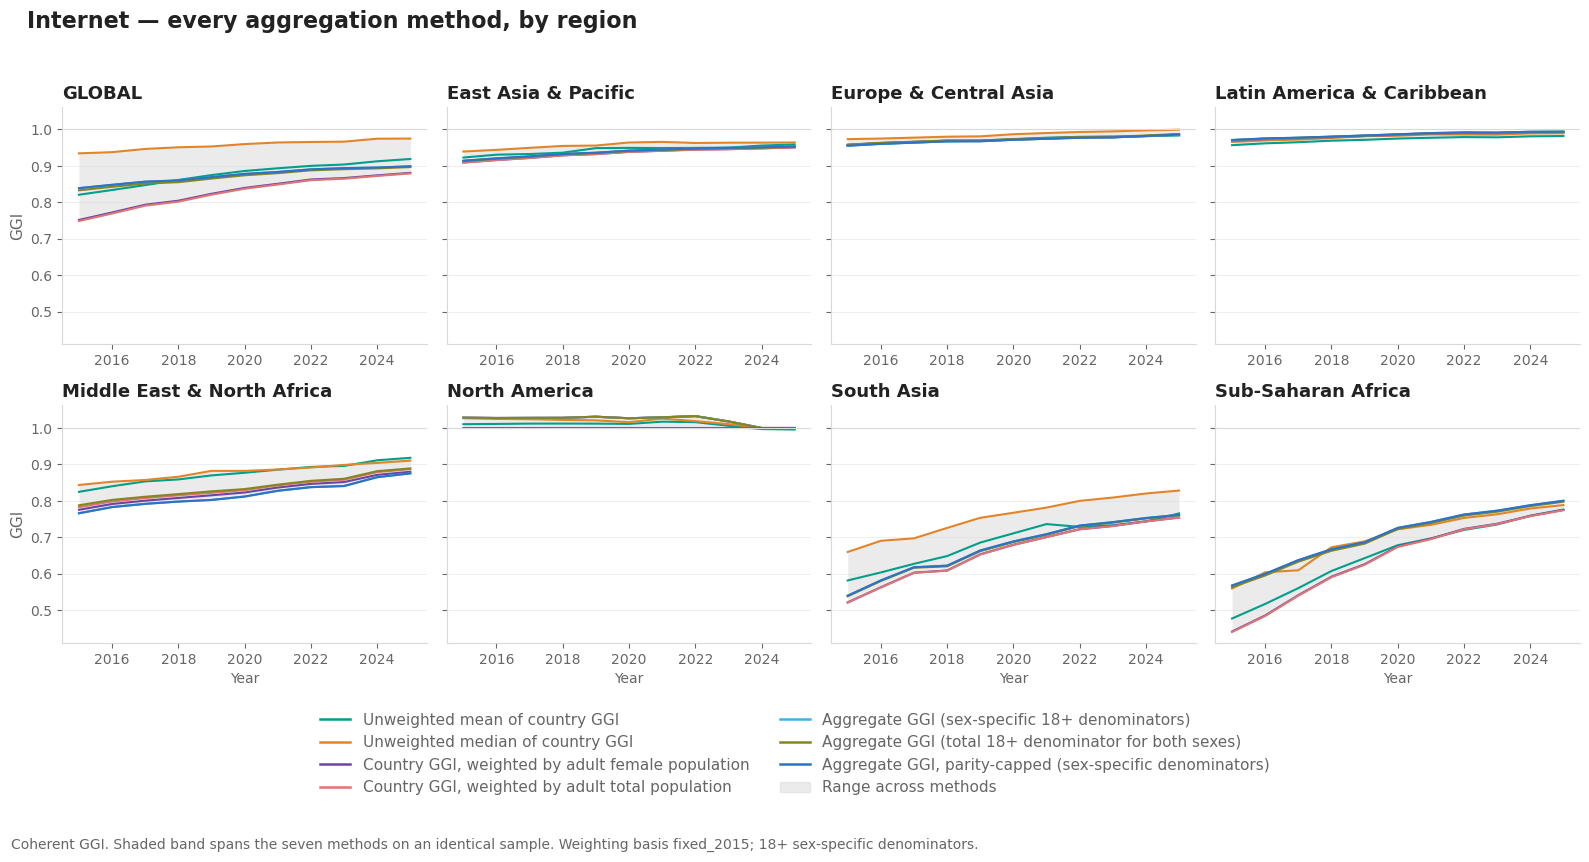

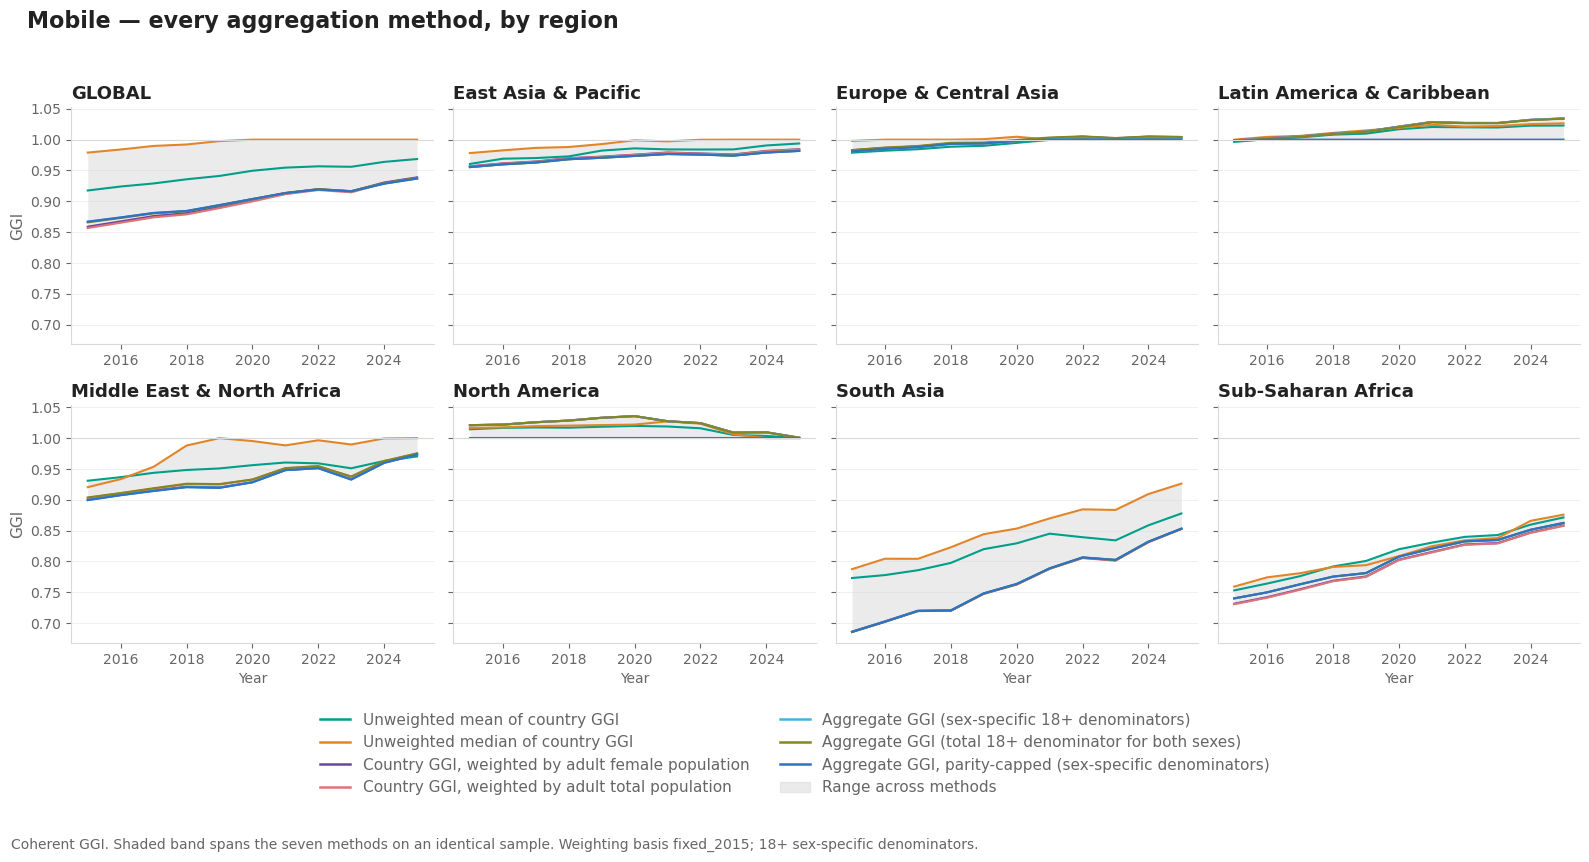

In [7]:
for indicator in params.COHERENT_GGI['indicators']:
    block = methods[(methods['indicator'] == indicator) & (methods['weight_basis'] == BASIS)]
    regions = [GLOBAL] + sorted(r for r in block['region'].unique() if r != GLOBAL)
    ncols = 4
    nrows = int(np.ceil(len(regions) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.6 * nrows), sharey=True)
    axes = axes.flatten()
    for ax, region in zip(axes, regions):
        sub = block[block['region'] == region].sort_values('year')
        lo = sub[METHOD_ORDER].min(axis=1)
        hi = sub[METHOD_ORDER].max(axis=1)
        ax.fill_between(sub['year'], lo, hi, color=GRID, alpha=0.5, linewidth=0)
        for method in METHOD_ORDER:
            ax.plot(sub['year'], sub[method], linewidth=1.5, color=METHOD_COLOUR[method])
        ax.axhline(1.0, color=GRID, linewidth=0.8)
        tidy(ax, title=region)
    for ax in axes[len(regions):]:
        ax.axis('off')
    # label the axis only where it sits under the plot, but keep ticks everywhere
    for idx, ax in enumerate(axes[:len(regions)]):
        if idx >= len(regions) - ncols:
            ax.set_xlabel('Year', fontsize=STYLE['tick_fs'] - 1, color=MUTED)
    for r in range(nrows):
        axes[r * ncols].set_ylabel('GGI', fontsize=STYLE['tick_fs'], color=MUTED)

    handles = [plt.Line2D([], [], color=METHOD_COLOUR[m], linewidth=1.8, label=METHOD_LABEL[m])
               for m in METHOD_ORDER]
    handles.append(mpatches.Patch(color=GRID, alpha=0.5, label='Range across methods'))
    fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
               fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.13))
    fig.suptitle(f'{indicator.capitalize()} — every aggregation method, by region',
                 fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
    caption(fig, f'Coherent GGI. Shaded band spans the seven methods on an identical sample. '
                 f'Weighting basis {BASIS}; 18+ sex-specific denominators.', y=-0.17)
    fig.tight_layout(rect=[0, 0.02, 1, 0.95])
    fig.savefig(FIGDIR / f'all_methods_by_region_{indicator}.png',
                dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  all_methods_by_region_{indicator}.png')

## 6. Why the summaries differ

Each step changes exactly **one** thing, so its delta belongs to that channel alone, and the steps
chain from the unweighted mean to the parity-capped aggregate.

| Channel | What changes |
| --- | --- |
| `country_composition` | restricting to countries with an age-aligned denominator |
| `extreme_country_values` | mean to median on the same countries |
| `population_weights` | each country weighted by its adult population |
| `ratio_of_means` | aggregating levels first, instead of averaging country ratios |
| `sex_population_structure` | each sex on its own denominator instead of one shared |
| `parity_ceiling` | capping the aggregate at parity |

  difference_channels_internet.png


  difference_channels_mobile.png


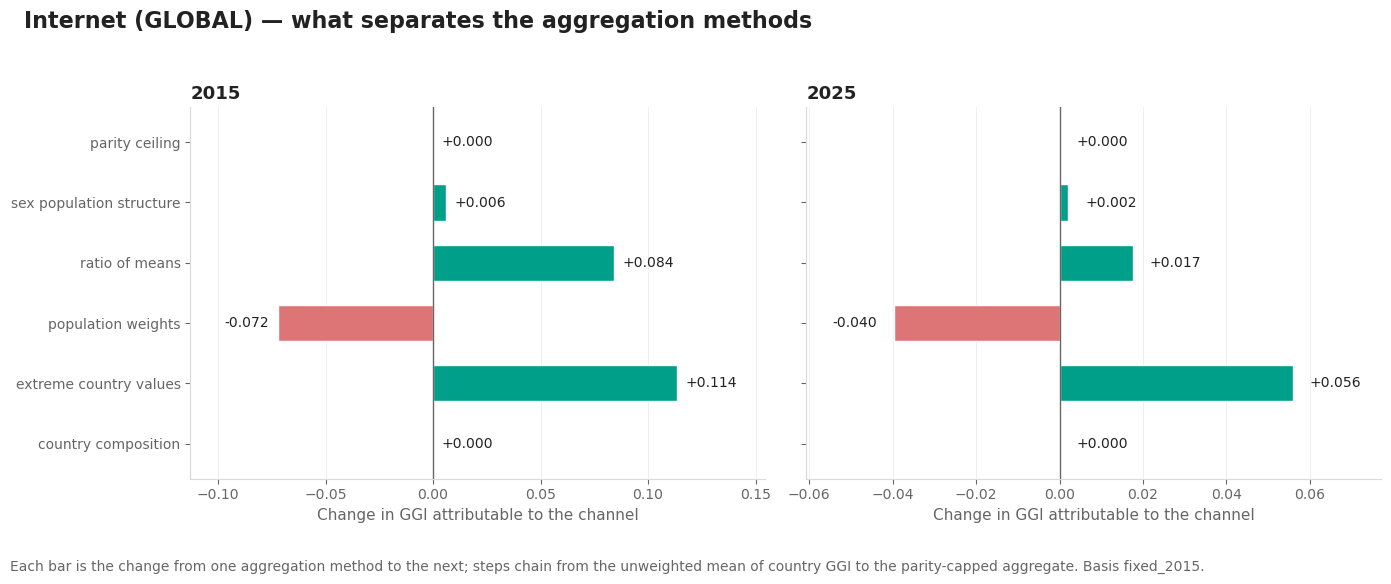

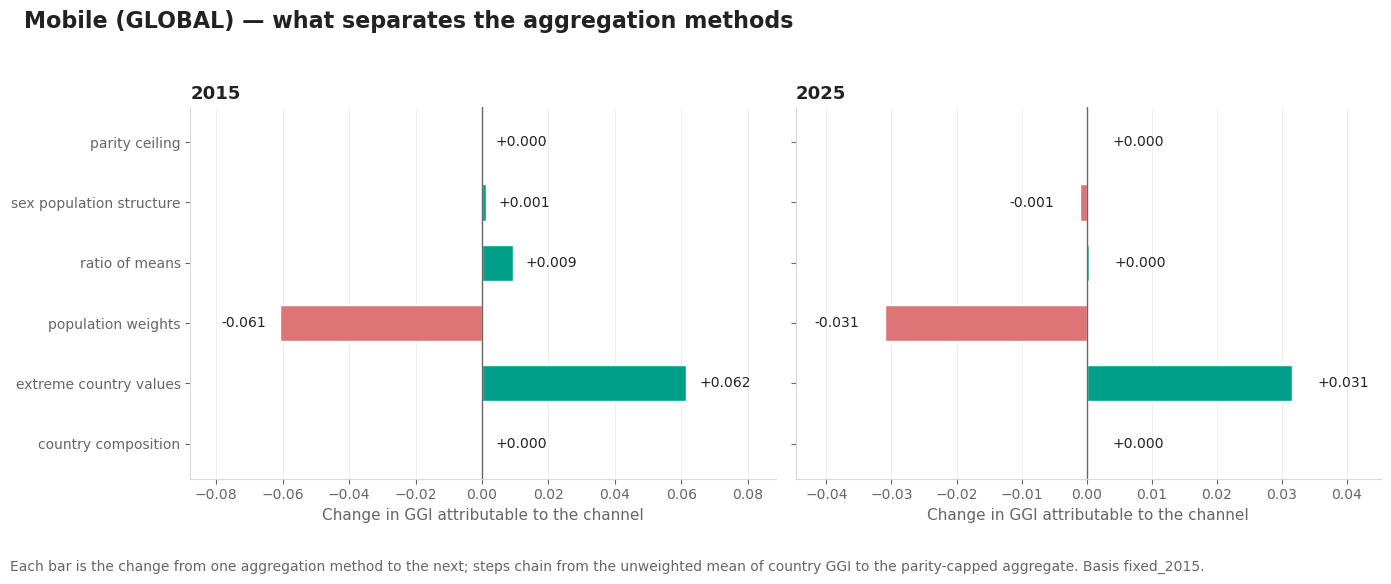

In [8]:
CHANNEL_ORDER = ['country_composition', 'extreme_country_values', 'population_weights',
                 'ratio_of_means', 'sex_population_structure', 'parity_ceiling']

for indicator in params.COHERENT_GGI['indicators']:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    for ax, year in zip(axes, [2015, 2025]):
        block = decomposition[(decomposition['indicator'] == indicator)
                              & (decomposition['weight_basis'] == BASIS)
                              & (decomposition['year'] == year)
                              & (decomposition['region'] == GLOBAL)]
        block = block.set_index('channel').reindex(CHANNEL_ORDER).reset_index()
        colours = [PALETTE[0] if d >= 0 else PALETTE[3] for d in block['delta'].fillna(0)]
        ax.barh(range(len(block)), block['delta'].fillna(0), color=colours,
                edgecolor='white', height=0.6)
        ax.axvline(0, color=MUTED, linewidth=1)
        ax.set_yticks(range(len(block)))
        ax.set_yticklabels([c.replace('_', ' ') for c in block['channel']])
        for i, d in enumerate(block['delta'].fillna(0)):
            ax.text(d + (0.004 if d >= 0 else -0.004), i, f'{d:+.3f}',
                    va='center', ha='left' if d >= 0 else 'right',
                    fontsize=STYLE['tick_fs'] - 1, color=INK)
        # value labels sit outside the bar, so the axis needs room or they run into the tick labels
        ax.margins(x=0.22)
        tidy(ax, title=f'{year}', xlabel='Change in GGI attributable to the channel')
        ax.grid(axis='y', visible=False)
        ax.grid(axis='x', color=GRID, linewidth=0.5, alpha=0.6)
        ax.invert_yaxis()

    fig.suptitle(f'{indicator.capitalize()} (GLOBAL) — what separates the aggregation methods',
                 fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
    caption(fig, 'Each bar is the change from one aggregation method to the next; steps chain from '
                 f'the unweighted mean of country GGI to the parity-capped aggregate. Basis {BASIS}.')
    fig.tight_layout(rect=[0, 0.02, 1, 0.94])
    fig.savefig(FIGDIR / f'difference_channels_{indicator}.png',
                dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  difference_channels_{indicator}.png')

In [9]:
# the same attribution per region, as a table
dec = decomposition[(decomposition['weight_basis'] == BASIS) & (decomposition['year'] == 2025)]
pivot = dec.pivot_table(index=['indicator', 'region'], columns='channel', values='delta')
display(pivot[CHANNEL_ORDER].round(4))
print('Table note: change in the regional GGI attributable to each aggregation channel, 2025; '
      f'weighting basis {BASIS}. Steps chain from the unweighted mean to the parity-capped aggregate.')

channel                               country_composition  \
indicator region                                            
internet  East Asia & Pacific                         0.0   
          Europe & Central Asia                       0.0   
          GLOBAL                                      0.0   
          Latin America & Caribbean                   0.0   
          Middle East & North Africa                  0.0   
          North America                               0.0   
          South Asia                                  0.0   
          Sub-Saharan Africa                          0.0   
mobile    East Asia & Pacific                         0.0   
          Europe & Central Asia                       0.0   
          GLOBAL                                      0.0   
          Latin America & Caribbean                   0.0   
          Middle East & North Africa                  0.0   
          North America                               0.0   
          South Asia                                  0.0   
          Sub-Saharan Africa                          0.0   

channel                               extreme_country_values  \
indicator region                                               
internet  East Asia & Pacific                         0.0056   
          Europe & Central Asia                       0.0159   
          GLOBAL                                      0.0560   
          Latin America & Caribbean                   0.0077   
          Middle East & North Africa                 -0.0077   
          North America                               0.0043   
          South Asia                                  0.0626   
          Sub-Saharan Africa                          0.0121   
mobile    East Asia & Pacific                         0.0062   
          Europe & Central Asia                      -0.0030   
          GLOBAL                                      0.0315   
          Latin America & Caribbean                   0.0035   
          Middle East & North Africa                  0.0297   
          North America                              -0.0003   
          South Asia                                  0.0484   
          Sub-Saharan Africa                          0.0045   

channel                               population_weights  ratio_of_means  \
indicator region                                                           
internet  East Asia & Pacific                    -0.0083          0.0019   
          Europe & Central Asia                   0.0027          0.0015   
          GLOBAL                                 -0.0397          0.0175   
          Latin America & Caribbean               0.0111          0.0004   
          Middle East & North Africa             -0.0310          0.0019   
          North America                           0.0043          0.0000   
          South Asia                             -0.0117          0.0063   
          Sub-Saharan Africa                     -0.0019          0.0234   
mobile    East Asia & Pacific                    -0.0097         -0.0020   
          Europe & Central Asia                   0.0007          0.0007   
          GLOBAL                                 -0.0310          0.0003   
          Latin America & Caribbean               0.0114         -0.0004   
          Middle East & North Africa              0.0047          0.0003   
          North America                           0.0004         -0.0000   
          South Asia                             -0.0254          0.0005   
          Sub-Saharan Africa                     -0.0137          0.0045   

channel                               sex_population_structure  parity_ceiling  
indicator region                                                                
internet  East Asia & Pacific                           0.0009          0.0000  
          Europe & Central Asia                        -0.0016          0.0000  
          GLOBAL                                       

Table note: change in the regional GGI attributable to each aggregation channel, 2025; weighting basis fixed_2015. Steps chain from the unweighted mean to the parity-capped aggregate.


## 7. Guidance for the manuscript

In [10]:
def guidance():
    """compose the standardisation note from the computed spreads"""
    lines = []
    tblb = comparison[comparison['weight_basis'] == BASIS]

    for ind in params.COHERENT_GGI['indicators']:
        g = methods[(methods['indicator'] == ind) & (methods['region'] == GLOBAL)
                    & (methods['weight_basis'] == BASIS)]
        for year in (2015, 2025):
            row = g[g['year'] == year]
            if row.empty:
                continue
            vals = row[METHOD_ORDER].iloc[0]
            lines.append(
                f"For {ind} in {year}, the global figure ranges from {vals.min():.3f} "
                f"({METHOD_LABEL[vals.idxmin()].lower()}) to {vals.max():.3f} "
                f"({METHOD_LABEL[vals.idxmax()].lower()}) — a spread of {vals.max()-vals.min():.3f} "
                'across methods on an identical sample.')

    ind = 'internet'
    g = methods[(methods['indicator'] == ind) & (methods['region'] == GLOBAL)
                & (methods['weight_basis'] == BASIS)]
    v15 = g[g['year'] == 2015][METHOD_ORDER].iloc[0]
    v25 = g[g['year'] == 2025][METHOD_ORDER].iloc[0]
    improvement = (v25 - v15).abs().max()
    if (v15.max() - v15.min()) > improvement:
        lines.append(
            f"For {ind} the 2015 spread across methods ({v15.max()-v15.min():.3f}) exceeds the "
            f"largest 2015-2025 improvement any single method reports ({improvement:.3f}). An "
            'unlabelled global figure is therefore less informative than the choice of method, and '
            'no trend statement should be made without naming the aggregation.')

    d = disagreement[disagreement['weight_basis'] == BASIS]
    moved = d[d['n_distinct_ranks'] > 1]
    if len(moved):
        by_ind = moved.groupby('indicator')['region'].apply(list).to_dict()
        for ind, regions in by_ind.items():
            lines.append(
                f"Regional ordering for {ind} is not method-invariant: "
                f"{', '.join(sorted(set(regions)))} change rank depending on the aggregation used. "
                'Any ranking claim must state the method.')
    else:
        lines.append('Regional ordering is identical under every method tested.')

    cov = coverage[~coverage['contemporaneous_weighting_possible']]
    if len(cov):
        lines.append(
            f"No age- and sex-specific population denominator exists for {', '.join(map(str, cov['year']))}. "
            'Population-weighted statistics for those years apply the 2015 population structure to '
            'later adoption rates and must be described that way; they are not weighted by the '
            'population of the year they describe.')

    lines.append(
        'Recommended default for the manuscript: report the **aggregate GGI on 18+ sex-specific '
        'population denominators**, because it is the only summary in which the regional numerator '
        'and denominator are themselves population quantities, and state the method in every '
        'caption. Where a country-level distribution is the subject rather than a regional total, '
        'the unweighted median is the appropriate summary — and should be named as such, since it '
        'sits systematically above the population-weighted figures.')

    return '\n\n'.join(lines)


text = guidance()
out = params.DOC / 'aggregation_methods.md'
out.write_text('# Aggregation methods — standardisation note\n\n'
               '<!-- generated by src/analysis/10_aggregation_methods.ipynb — do not edit by hand -->\n\n'
               + text + '\n')
print(f'written to {out.relative_to(params.ROOT)}\n')
print(text)

written to doc/aggregation_methods.md

For internet in 2015, the global figure ranges from 0.749 (country ggi, weighted by adult total population) to 0.935 (unweighted median of country ggi) — a spread of 0.186 across methods on an identical sample.

For internet in 2025, the global figure ranges from 0.879 (country ggi, weighted by adult total population) to 0.975 (unweighted median of country ggi) — a spread of 0.096 across methods on an identical sample.

For mobile in 2015, the global figure ranges from 0.857 (country ggi, weighted by adult total population) to 0.979 (unweighted median of country ggi) — a spread of 0.122 across methods on an identical sample.

For mobile in 2025, the global figure ranges from 0.937 (aggregate ggi (sex-specific 18+ denominators)) to 1.000 (unweighted median of country ggi) — a spread of 0.063 across methods on an identical sample.

For internet the 2015 spread across methods (0.186) exceeds the largest 2015-2025 improvement any single method reports

## Notes

- Figures in `outputs/fig/aggregation/`; tables in `outputs/tables/` under `aggregation_`.
- Denominators are 18+ by sex, matching the age group the models are fitted on. Total-population
  weighting is computed and reported (`mean_pop_weighted_total`), never substituted silently.
- `fixed_2015` is the primary weighting basis because no 2025 population exists;
  `contemporaneous` is included for 2015–2024 as a check.
- Facebook-count ratios are **not** an aggregation of the GGI and are deliberately absent here. They
  are model *inputs* (`fb_18_999_r`), not a summary of the outcome; anywhere the manuscript uses
  them as a regional gender-gap statistic is a separate issue from this audit.